In [ ]:
import numpy as np
import matplotlib.pyplot as plt
path = r"Z:\Jasmine_Laurence\summary_plots\CCA\cca_vel_results_balanced_bins_pos.npz"
results = np.load(path, allow_pickle=True)

In [49]:
train_explore = results["train_explore"].item()
train_homing = results["train_homing"].item()
cond_list = ["shelter_only", "barrier_pre_flip", "barrier_post_flip"]
n_components = 5

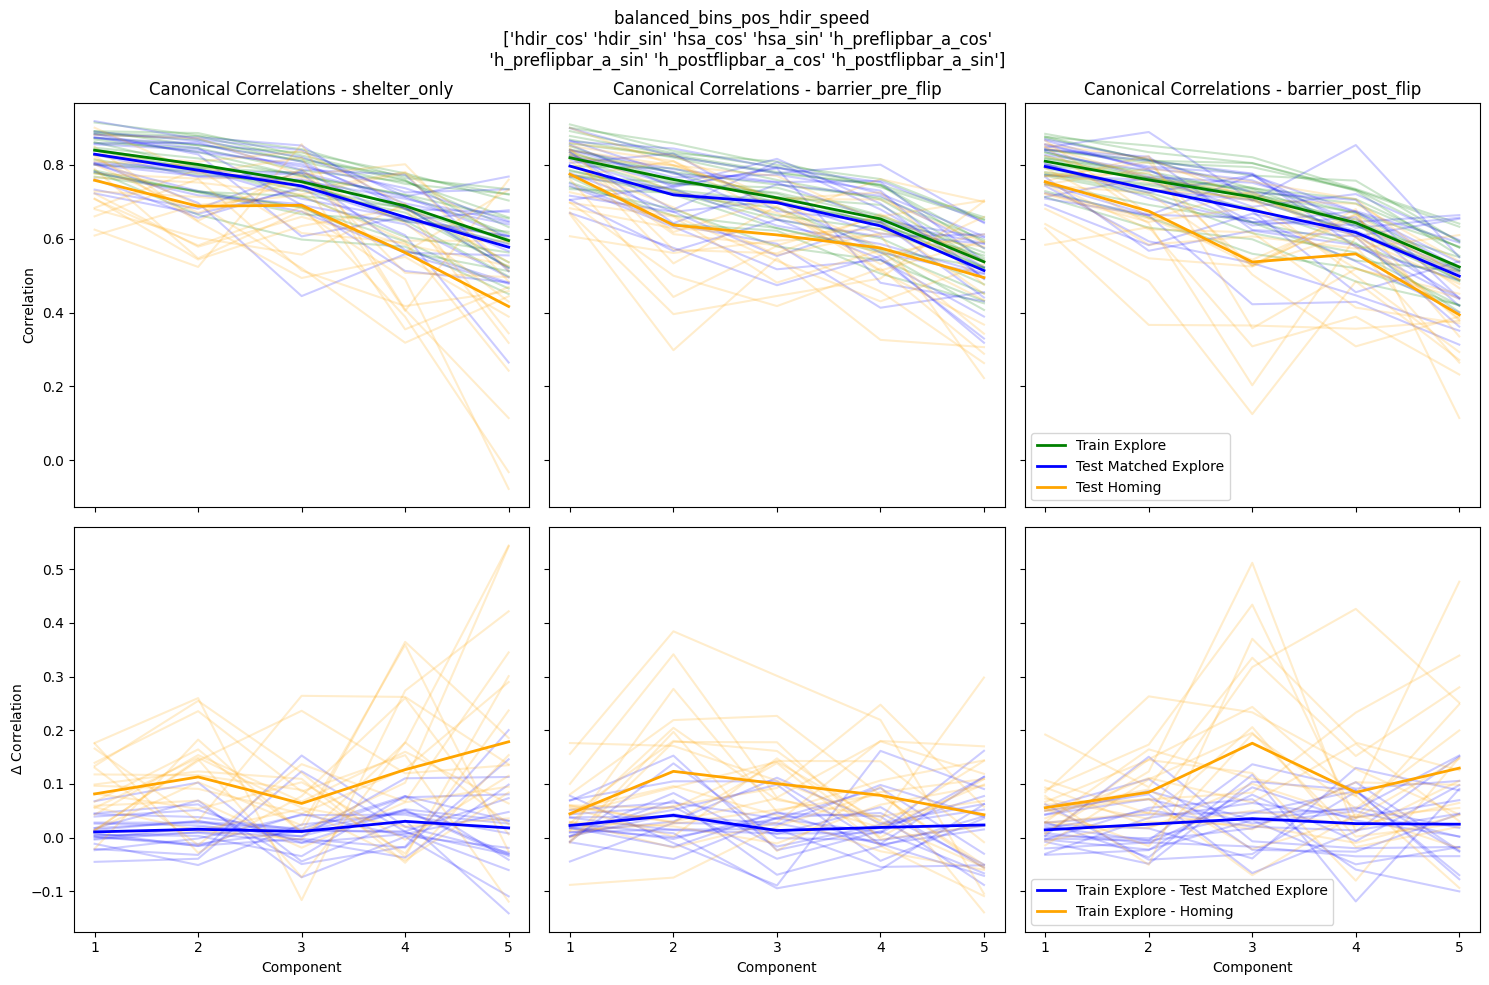

In [50]:
"""Visualize the canonical correlations for train explore vs test homing for each condition"""
fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey='row')
for c in range(len(cond_list)):
    axs[0,c].plot(train_explore['train_canonical_corr'][:, c, :].T, color = 'green', alpha = 0.2)
    axs[0,c].plot(train_explore['test_canonical_corr'][:, c, :].T, color = 'blue', alpha = 0.2)
    axs[0,c].plot(train_explore['homing_canonical_corr'][:, c, :].T, color = 'orange', alpha = 0.2)
    axs[0,c].plot(np.mean(train_explore['train_canonical_corr'][:, c, :], axis = 0), color = 'green', linewidth = 2, label = "Train Explore")
    axs[0,c].plot(np.mean(train_explore['test_canonical_corr'][:, c, :], axis = 0), color = 'blue', linewidth = 2, label = "Test Matched Explore")
    axs[0,c].plot(np.mean(train_explore['homing_canonical_corr'][:, c, :], axis = 0), color = 'orange', linewidth = 2, label = "Test Homing")
    axs[0,c].set_title(f"Canonical Correlations - {cond_list[c]}")
    axs[0,c].set_xticks(range(n_components))
    axs[0,c].set_xticklabels(range(1, n_components+1))
    axs[1,c].plot(train_explore['train_canonical_corr'][:, c, :].T - train_explore['test_canonical_corr'][:, c, :].T, color = 'blue', alpha = 0.2)
    axs[1,c].plot(train_explore['train_canonical_corr'][:, c, :].T - train_explore['homing_canonical_corr'][:, c, :].T, color = 'orange', alpha = 0.2)
    axs[1,c].plot(np.mean(train_explore['train_canonical_corr'][:, c, :].T - train_explore['test_canonical_corr'][:, c, :].T, axis = 1), color = 'blue', linewidth = 2, label = "Train Explore - Test Matched Explore")
    axs[1,c].plot(np.mean(train_explore['train_canonical_corr'][:, c, :].T - train_explore['homing_canonical_corr'][:, c, :].T, axis = 1), color = 'orange', linewidth = 2, label = "Train Explore - Homing")
    axs[1,c].set_xticks(range(n_components))
    axs[1,c].set_xticklabels(range(1, n_components+1))
    axs[1,c].set_xlabel("Component")
axs[1,0].set_ylabel(r"$\Delta$ Correlation")
axs[0,0].set_ylabel("Correlation")
axs[0,2].legend()
axs[1,2].legend()
plt.suptitle(f"{results['method']} \n {results['behavioral_var']}")
plt.tight_layout()

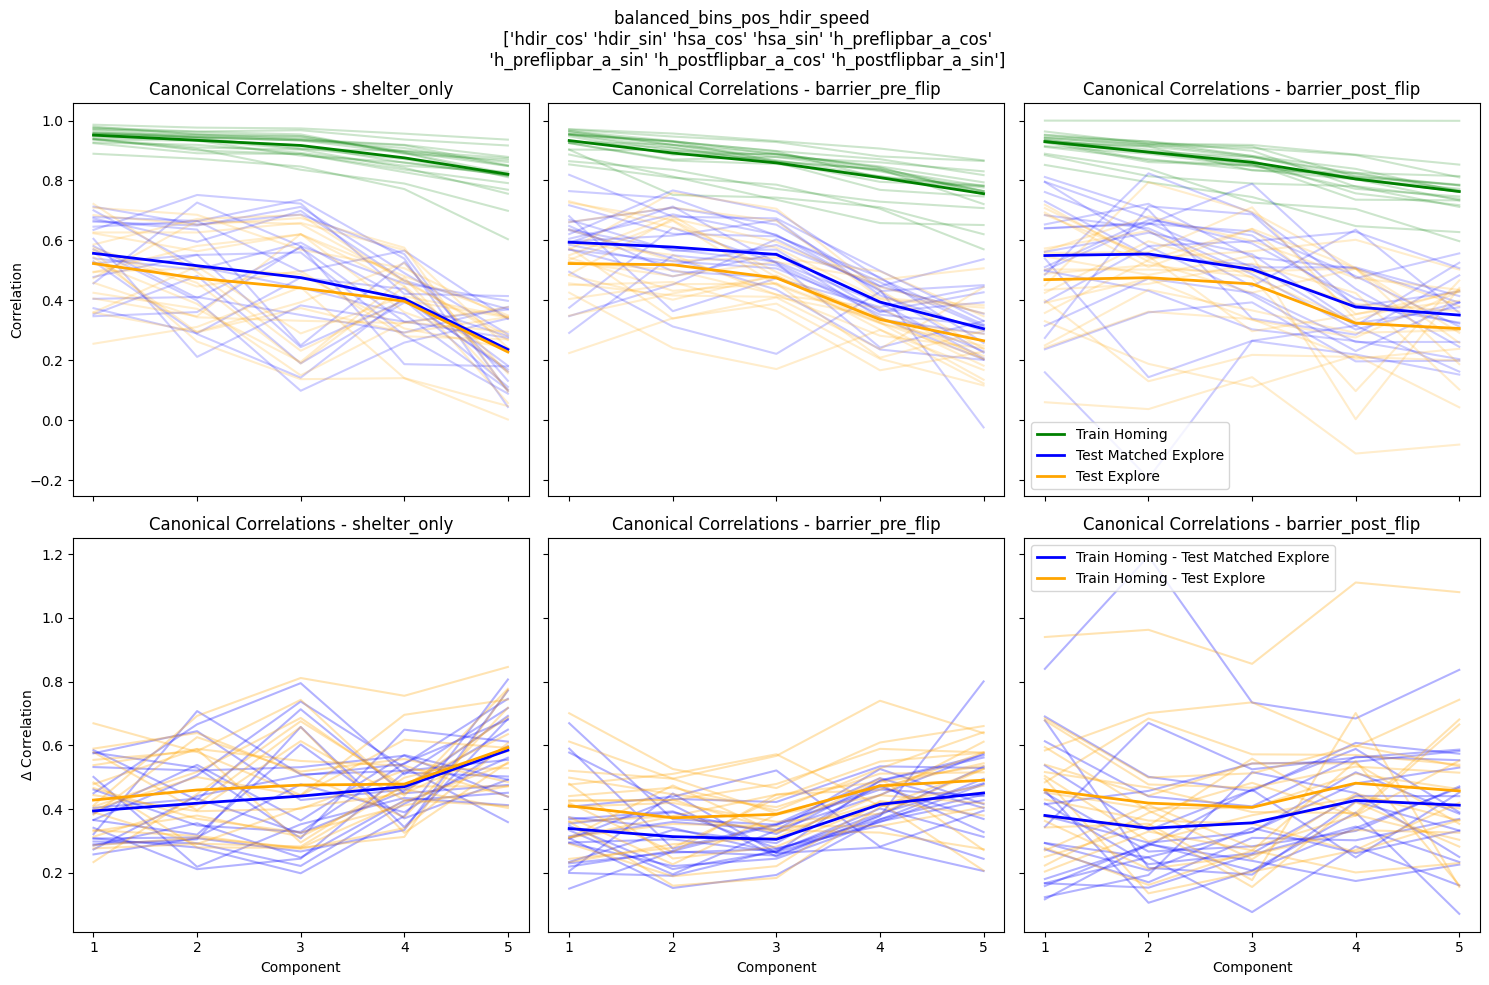

In [51]:
"""Visualize the canonical correlations for train homing vs test explore for each condition"""

fig, axs = plt.subplots(2, 3, figsize=(15, 10), sharex=True, sharey='row')
for c in range(3):
    axs[0,c].plot(train_homing['train_h_canonical_corr'][:, c, :].T, color = 'green', alpha = 0.2)
    axs[0,c].plot(train_homing['exp_match_canonical_corr'][:, c, :].T, color = 'blue', alpha = 0.2)
    axs[0,c].plot(train_homing['test_exp_canonical_corr'][:, c, :].T, color = 'orange', alpha = 0.2)
    axs[0,c].plot(np.mean(train_homing['train_h_canonical_corr'][:, c, :], axis = 0), color = 'green', linewidth = 2, label = "Train Homing")
    axs[0,c].plot(np.mean(train_homing['exp_match_canonical_corr'][:, c, :], axis = 0), color = 'blue', linewidth = 2, label = "Test Matched Explore")
    axs[0,c].plot(np.mean(train_homing['test_exp_canonical_corr'][:, c, :], axis = 0), color = 'orange', linewidth = 2, label = "Test Explore")
    axs[0,c].set_title(f"Canonical Correlations - {cond_list[c]}")
    axs[0,c].set_xticks(range(n_components))
    axs[0,c].set_xticklabels(range(1, n_components+1))
    axs[1,c].plot(train_homing['train_h_canonical_corr'][:, c, :].T - train_homing['exp_match_canonical_corr'][:, c, :].T, color = 'blue', alpha=0.3)
    axs[1,c].plot(train_homing['train_h_canonical_corr'][:, c, :].T - train_homing['test_exp_canonical_corr'][:, c, :].T, color = 'orange', alpha = 0.3)
    axs[1,c].plot(np.mean(train_homing['train_h_canonical_corr'][:, c, :].T - train_homing['exp_match_canonical_corr'][:, c, :].T, axis = 1), color = 'blue', linewidth = 2, label = "Train Homing - Test Matched Explore")
    axs[1,c].plot(np.mean(train_homing['train_h_canonical_corr'][:, c, :].T - train_homing['test_exp_canonical_corr'][:, c, :].T, axis = 1), color = 'orange', linewidth = 2, label = "Train Homing - Test Explore")
    axs[1,c].set_title(f"Canonical Correlations - {cond_list[c]}")
    axs[1,c].set_xticks(range(n_components))
    axs[1,c].set_xticklabels(range(1, n_components+1))
    axs[1,c].set_xlabel("Component")
axs[1,0].set_ylabel(r"$\Delta$ Correlation")
axs[0,0].set_ylabel("Correlation")
axs[0,2].legend()
axs[1,2].legend()
plt.suptitle(f"{results['method']} \n {results['behavioral_var']}")
plt.tight_layout()